## Dallo spettro al filtro: FFT, STFT e filtri audio (passa-basso, passa-alto, equalizzatore)



Al termine di questa lezione saprai:
- calcolare e interpretare lo spettro di ampiezza di un segnale audio tramite FFT;
- calcolare una STFT e leggere uno spettrogramma;
- individuare le componenti frequenziali dominanti di un segnale (fondamentale, armoniche, formanti);
- progettare filtri FIR e IIR (Butterworth, Chebyshev) passa-basso e passa-alto con `scipy.signal`;
- valutare l'effetto di un filtro per ascolto e per confronto spettrale;
- costruire un equalizzatore grafico a N bande.


## Collegamento con lezione precedente

Nella lezione precedente abbiamo visto che un segnale continuo può essere rappresentato senza perdita di
informazione tramite campioni discreti, a patto di campionare a una frequenza $f_s$ almeno doppia della
massima frequenza presente nel segnale (**teorema di Nyquist**, $f_s \geq 2 f_{max}$). Campionando al di
sotto di questa soglia si ottiene **aliasing**: componenti ad alta frequenza vengono scambiate per
componenti a bassa frequenza.

Oggi il segnale è correttamente campionato: la domanda diventa **"che frequenze contiene?"** (FFT/STFT,
prima parte della lezione) e poi **"come modifico selettivamente quelle frequenze?"** (filtri ed
equalizzatore, seconda parte).


## Setup

In questo notebook lavoriamo per default con **segnali sintetici** (tono puro, accordo musicale, voce
sintetizzata per formanti, rumore bianco), così da non dipendere da file audio esterni. Se disponi di
registrazioni reali, imposta `USE_SYNTHETIC = False` e indica i percorsi dei file nella cella successiva:
la parte restante del notebook funziona identica in entrambi i casi.


In [1]:
import numpy as np
import scipy.signal as sig
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
import librosa
import librosa.display
from IPython.display import Audio, display

try:
    import sounddevice as sd
    HAS_SOUNDDEVICE = True
except Exception:
    HAS_SOUNDDEVICE = False

FS = 22050          # frequenza di campionamento di lavoro (Hz)
DURATA = 3.0        # durata dei segnali campione (s)

USE_SYNTHETIC = True

# Se USE_SYNTHETIC = False, indicare qui i percorsi ai file reali (mono, stesso fs)
FILE_VOCE   = "audio/voce.wav"
FILE_MUSICA = "audio/musica.wav"
FILE_RUMORE = "audio/rumore.wav"
FILE_TONO   = "audio/tono.wav"

def play(x, fs=FS):
    """Riproduce un segnale audio (compatibile Colab e locale)."""
    display(Audio(x, rate=fs))


### Generazione dei segnali sintetici campione

Quattro segnali che riutilizzeremo per tutta la lezione: un **tono puro**, un **accordo musicale**
(più armoniche stabili), una **voce sintetizzata per formanti** (sintesi a risonatori: un breve
enunciato con 4 "sillabe"/vocali diverse, transizioni di formanti, declinazione dell'intonazione,
micro-variazioni di periodo/ampiezza e un leggero soffio) e un **rumore bianco**.

La voce è una sintesi approssimata, non una registrazione reale: serve a mostrare in modo controllato
(e riproducibile) formanti che si spostano nel tempo, così da rendere leggibile l'effetto nello
spettrogramma. Se disponi di registrazioni vere, sostituiscile pure impostando `USE_SYNTHETIC = False`.


In [2]:
def synth_tone(fs=FS, durata=DURATA, f0=440.0):
    """Genera un tono puro: una singola sinusoide a frequenza f0.
    È il segnale più semplice possibile: nello spettro deve produrre UN SOLO
    picco, esattamente a f0 Hz (lo verifichiamo nella Demo 1)."""
    t = np.arange(int(fs * durata)) / fs           # asse dei tempi, un campione ogni 1/fs secondi
    x = np.sin(2 * np.pi * f0 * t)                  # sinusoide: ampiezza=1, frequenza=f0, fase=0
    return x / np.max(np.abs(x))                    # normalizzazione: picco portato a ±1

def synth_chord(fs=FS, durata=DURATA, freqs=(261.63, 329.63, 392.00), n_armoniche=3, decadimento=2.5):
    """Genera un accordo musicale (es. Do maggiore): somma, per ciascuna delle
    frequenze fondamentali in `freqs`, della fondamentale stessa e delle sue prime
    `n_armoniche` armoniche (multipli interi, con ampiezza decrescente 1/k), per
    dare un timbro più ricco di una singola sinusoide. Un inviluppo esponenziale
    decrescente simula il decadimento naturale di una nota pizzicata/percossa."""
    t = np.arange(int(fs * durata)) / fs
    x = np.zeros_like(t)
    for f in freqs:                                 # una nota per ciascuna frequenza fondamentale
        for k in range(1, n_armoniche + 1):          # k=1 fondamentale, k=2,3,... armoniche superiori
            x += (1.0 / k) * np.sin(2 * np.pi * f * k * t)  # armoniche più alte pesano meno (1/k)
    x *= np.exp(-t / decadimento)                    # inviluppo: il suono si smorza nel tempo
    return x / np.max(np.abs(x))                     # normalizzazione: picco portato a ±1

def _risuonatore(x, fs, formanti, larghezze):
    """Filtra il segnale di eccitazione `x` con una batteria di risonatori del
    secondo ordine (uno per ciascuna formante) e ne somma le uscite. Ogni
    risonatore è un filtro IIR a due poli, centrato sulla frequenza `f` e con
    larghezza di banda `bw`: è il modo standard di simulare la risonanza del
    tratto vocale che dà origine ai formanti di una vocale."""
    y = np.zeros_like(x)
    for f, bw in zip(formanti, larghezze):
        r = np.exp(-np.pi * bw / fs)                 # raggio dei poli: più bw è grande, più il risonatore si smorza in fretta
        theta = 2 * np.pi * f / fs                    # angolo dei poli: posiziona il picco di risonanza a frequenza f
        b = [1 - r]                                   # coefficienti del filtro IIR (numeratore)
        a = [1, -2 * r * np.cos(theta), r ** 2]        # coefficienti del filtro IIR (denominatore, poli complessi coniugati)
        y += sig.lfilter(b, a, x)                     # applica il risonatore e accumula il contributo di questa formante
    return y

def _treno_impulsi_naturale(fs, durata, f0_iniziale=140.0, f0_finale=100.0,
                             jitter=0.03, shimmer=0.08, seed=0):
    """Genera il segnale di eccitazione glottale: un treno di impulsi (uno per
    ogni chiusura delle corde vocali) che, filtrato dai risonatori, diventerà la
    voce. Per renderlo meno robotico rispetto a un treno di impulsi perfettamente
    periodico si aggiungono tre effetti tipici della voce naturale:
    - declinazione: la frequenza fondamentale (F0, l'intonazione) scende
      linearmente da `f0_iniziale` a `f0_finale` lungo l'enunciato;
    - jitter: piccola variazione casuale del periodo tra un impulso e il successivo;
    - shimmer: piccola variazione casuale dell'ampiezza di ciascun impulso.
    """
    rng = np.random.default_rng(seed)
    n = int(fs * durata)
    impulsi = np.zeros(n)
    i = 0
    while i < n:
        frac = i / n                                          # posizione relativa nell'enunciato (0 -> 1)
        f0_i = f0_iniziale + (f0_finale - f0_iniziale) * frac  # F0 corrente: interpolazione lineare (declinazione)
        f0_i *= (1 + rng.normal(0, jitter))                    # jitter: perturbazione casuale della F0/periodo
        impulsi[i] = 1.0 + rng.normal(0, shimmer)               # shimmer: perturbazione casuale dell'ampiezza dell'impulso
        periodo = max(1, int(fs / max(f0_i, 1.0)))              # periodo in campioni corrispondente a f0_i
        i += periodo                                            # avanza al prossimo impulso glottale
    return impulsi

def synth_voice(fs=FS, durata=DURATA, seed=0):
    """Voce sintetizzata per formanti: sintetizza un breve enunciato come
    sequenza di 4 'sillabe' (le vocali /a/-/e/-/i/-/u/, ciascuna con i propri
    formanti caratteristici), separate da brevi pause, con transizioni morbide
    tra una sillaba e l'altra, declinazione di F0, jitter/shimmer (dal treno di
    impulsi) e un leggero soffio finale. Non è una registrazione reale, ma
    un'approssimazione pensata per mostrare in modo controllato e riproducibile
    formanti che SI SPOSTANO nel tempo (utile per lo spettrogramma)."""
    rng = np.random.default_rng(seed)
    # Frequenze dei primi 3 formanti (F1, F2, F3, in Hz) tipiche di ciascuna vocale
    vocali = [
        (700, 1220, 2600),   # /a/
        (500, 1750, 2450),   # /e/
        (280, 2250, 2890),   # /i/
        (310, 870, 2250),    # /u/
    ]
    larghezze = (80, 90, 120)                         # larghezza di banda (Hz) di F1, F2, F3 (uguale per tutte le vocali)
    n_sillabe = len(vocali)
    pausa = 0.08                                      # durata (s) del breve silenzio tra due sillabe consecutive
    dur_sillaba = (durata - pausa * (n_sillabe - 1)) / n_sillabe  # durata di ciascuna sillaba, dato il totale `durata`

    impulsi_full = _treno_impulsi_naturale(fs, durata, seed=seed)  # eccitazione glottale per l'intero enunciato
    voce_out = np.zeros(int(fs * durata))
    pos = 0                                           # cursore (in campioni) di scrittura dentro voce_out
    for formanti in vocali:                           # una sillaba per ciascun set di formanti (una vocale)
        n_seg = int(fs * dur_sillaba)
        fine = min(pos + n_seg, len(impulsi_full))
        seg_impulsi = impulsi_full[pos:fine]          # porzione di eccitazione dedicata a questa sillaba
        seg = _risuonatore(seg_impulsi, fs, formanti, larghezze)  # applica i formanti di questa vocale
        # inviluppo a coseno rialzato: attacco/rilascio morbidi, per evitare click
        # udibili nel punto di giunzione tra una sillaba e la successiva
        fade = max(1, min(300, len(seg) // 4))
        env = np.ones(len(seg))
        env[:fade] = 0.5 * (1 - np.cos(np.pi * np.arange(fade) / fade))   # fade-in
        env[-fade:] = 0.5 * (1 + np.cos(np.pi * np.arange(fade) / fade))  # fade-out
        seg = seg * env
        fine_voce = min(pos + len(seg), len(voce_out))
        voce_out[pos:fine_voce] += seg[: fine_voce - pos]   # scrive la sillaba nella posizione corrente
        pos += len(seg) + int(fs * pausa)                    # avanza il cursore oltre la sillaba + la pausa successiva
        if pos >= len(voce_out):
            break

    soffio = rng.normal(0, 1, len(voce_out)) * 0.02   # rumore bianco a bassissima energia: simula il "soffio" della voce
    voce_out = voce_out + soffio
    picco = np.max(np.abs(voce_out))
    return voce_out / picco if picco > 0 else voce_out  # normalizzazione finale: picco portato a ±1

def synth_noise(fs=FS, durata=DURATA, seed=0):
    """Genera rumore bianco: campioni indipendenti da una gaussiana (media 0,
    varianza 1). A differenza di tono/accordo/voce, la sua energia è distribuita
    su TUTTE le frequenze in modo (statisticamente) uniforme: nello spettro non
    ci aspettiamo picchi, ma un livello piatto e "sporco" (lo vedremo nella Demo 1
    e nella Demo 2)."""
    rng = np.random.default_rng(seed)                 # generatore pseudo-casuale con seed fisso -> risultato riproducibile
    x = rng.normal(0, 1, int(fs * durata))             # campioni gaussiani indipendenti (rumore bianco)
    return x / np.max(np.abs(x)) * 0.5                 # normalizzato e riportato a un volume più contenuto (picco ±0.5)

# Selezione della sorgente dei 4 segnali campione: sintesi (default, sempre disponibile)
# oppure registrazioni reali su disco, se l'istruttore le fornisce e imposta USE_SYNTHETIC = False
if USE_SYNTHETIC:
    tono   = synth_tone()
    musica = synth_chord()
    voce   = synth_voice()
    rumore = synth_noise()
else:
    tono,   _ = librosa.load(FILE_TONO,   sr=FS, mono=True)   # librosa.load ricampiona automaticamente a sr=FS
    musica, _ = librosa.load(FILE_MUSICA, sr=FS, mono=True)
    voce,   _ = librosa.load(FILE_VOCE,   sr=FS, mono=True)
    rumore, _ = librosa.load(FILE_RUMORE, sr=FS, mono=True)

segnali = {"tono": tono, "musica": musica, "voce": voce, "rumore": rumore}
print({k: v.shape for k, v in segnali.items()})  # controllo rapido: stessa fs per tutti, durata attesa in campioni


{'tono': (66150,), 'musica': (66150,), 'voce': (66150,), 'rumore': (66150,)}


In [3]:
play(tono)

In [4]:
play(musica)

In [5]:
play(voce)

In [6]:
play(rumore)

---
## Parte 1 — Dal tempo alla frequenza: FFT e STFT


### Cos'è la Trasformata di Fourier 

L'idea di fondo è che **qualunque segnale nel tempo può essere descritto come somma di sinusoidi** a
frequenze, ampiezze e fasi diverse (per segnali periodici: **serie di Fourier**; per segnali generici:
**Trasformata di Fourier**, FT). La FT è la funzione matematica che, dato un segnale nel tempo, restituisce
"quanto" di ciascuna frequenza è presente — cioè il suo **spettro**.

Un segnale audio digitale non è però una funzione continua ma una sequenza di $N$ campioni: per questo si
usa la sua versione discreta, la **DFT** (Discrete Fourier Transform). Calcolare la DFT nel modo diretto
costa $O(N^2)$ operazioni; la **FFT** (Fast Fourier Transform, algoritmo di Cooley–Tukey, 1965) calcola lo
*stesso identico risultato* in $O(N \log N)$: è il motivo per cui, in pratica, si usa sempre la FFT anche
per segnali audio con centinaia di migliaia di campioni.

**In sintesi:** FT/serie di Fourier = concetto matematico (segnale continuo); DFT = versione per segnali
campionati; FFT = algoritmo efficiente per calcolare la DFT. Il risultato che otteniamo — ampiezza (e fase)
per ciascuna frequenza — è lo **spettro** del segnale.

### Come si calcola, intuitivamente

L'idea più utile per capire il meccanismo è pensare alla trasformata come a un test di **quanto il segnale
assomiglia a un'onda di riferimento**, ripetuto per ogni frequenza possibile.

Per sapere quanto di una certa frequenza $f$ è presente nel segnale, si prende una sinusoide di riferimento
a quella frequenza, la si moltiplica campione per campione con il segnale, e si sommano tutti i prodotti.
Se il segnale contiene davvero una componente a frequenza $f$, i prodotti tenderanno ad avere segno
concorde e la somma risulterà grande; se quella frequenza non è presente, i prodotti saranno un miscuglio
di segni che si cancellano a vicenda e la somma resterà vicina a zero. Questa operazione — moltiplica e
somma — è una **correlazione**: misura quanto il segnale "combacia" con quell'onda di riferimento.

Un'analogia utile: immagina una fila di diapason, ciascuno accordato su una frequenza diversa. Fai
"risuonare" il segnale contro ciascun diapason: quelli accordati su frequenze davvero presenti nel segnale
vibreranno forte, gli altri resteranno quasi immobili. L'ampiezza di vibrazione di ciascun diapason è,
concettualmente, il valore dello spettro a quella frequenza.

Un dettaglio tecnico: una componente a frequenza $f$ può avere una fase qualunque, quindi un solo test con
un coseno non basterebbe — servirebbe anche un test con un seno, per non perdere componenti sfasate. Per
questo la formula usa un esponenziale complesso, che è un modo compatto per fare contemporaneamente il
test con coseno e con seno:

$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-i 2\pi k n / N}$$

Per ogni frequenza candidata $k$, questa formula moltiplica tutto il segnale per il riferimento a quella
frequenza e somma: esattamente il procedimento descritto sopra. Il risultato $X[k]$ è un numero complesso il
cui modulo è l'ampiezza (quello che vediamo nei grafici, con `np.abs`) e il cui angolo è la fase (che qui
scartiamo). Ripetuto per ogni $k$ da 0 a $N-1$ si ottiene l'intero spettro — calcolato così, "a forza
bruta", costa $N$ moltiplicazioni-somme per ciascuna delle $N$ frequenze, cioè $O(N^2)$ in totale: è
esattamente da qui che nasce il costo della DFT diretta menzionato sopra. La FFT non cambia il risultato,
lo calcola in modo identico punto per punto: è solo un modo più furbo di eseguire le stesse somme
sfruttando simmetrie e ridondanze (dividendo ricorsivamente il segnale in campioni pari e dispari), evitando
di ripetere calcoli già fatti — da qui il costo ridotto a $O(N \log N)$.

### Risoluzione in frequenza: cosa indica Δf

$$\Delta f = \frac{f_s}{N}$$

$\Delta f$ è la **distanza tra due righe consecutive dello spettro calcolato**, cioè la più piccola
differenza di frequenza che la FFT è in grado di distinguere con gli $N$ campioni a disposizione. Esempio:
con $f_s = 22050$ Hz e $N = 1024$ campioni, $\Delta f \approx 21.5$ Hz — due componenti più vicine di
così non si vedrebbero come picchi separati. Più campioni analizzo (N grande), più $\Delta f$ si riduce e
più lo spettro è "risolto".

### Quando si usano zero-padding e windowing

Partiamo dal "perché", non dalla formula.

**Windowing — perché serve.** La FFT assume matematicamente che il pezzo di segnale analizzato si ripeta
all'infinito. Ma un pezzo finito preso da una registrazione reale quasi mai finisce esattamente dove
comincia in modo "liscio": se lo ripetessimo, tra un'istanza e la successiva ci sarebbe un salto brusco,
una discontinuità. Un salto brusco, spettralmente, è come un "click" — e un click contiene energia sparsa
su tutte le frequenze. Questa energia spuria si somma al vero contenuto del segnale e "sporca" i bin
vicini al picco reale: è lo **spectral leakage**. Il **windowing** risolve il problema moltiplicando il
pezzo di segnale per una funzione che va dolcemente a zero ai due estremi (finestra di Hann, Hamming, ecc.)
invece di tagliarlo di netto: niente più salto brusco, niente più "click", leakage molto ridotto (lo si
vede bene nella demo qui sotto: la curva senza finestra ha code lunghe, quella con la finestra di Hann no).
*Quando si usa:* praticamente sempre, ogni volta che si analizza un pezzo finito di un segnale più lungo —
cioè quasi sempre, con l'audio reale. Nella STFT è obbligatorio, perché ogni finestra temporale che scorre
è comunque un pezzo "tagliato" dal segnale continuo. Il prezzo da pagare: la finestra allarga leggermente
il picco (un po' meno risoluzione in frequenza) — è uno scambio, non un pasto gratis.

**Zero-padding — perché serve.** Il problema qui è diverso: con pochi campioni (N piccolo) la FFT restituisce
pochi punti in frequenza (Δf = fs/N è grande), e lo spettro appare "a scalini", spigoloso, difficile da
leggere con precisione. Lo **zero-padding** aggiunge zeri in coda al segnale prima di calcolare la FFT
(es. porta 128 campioni veri a 4096, aggiungendo campioni finti a zero). Questo non aggiunge nessuna
informazione reale — quegli zeri non sono audio registrato — ma fa sì che la FFT calcoli più punti sulla
*stessa* curva spettrale sottostante, rendendola più liscia e più leggibile a video (nella demo, i pochi
punti "a pallini" senza padding cadono esattamente sopra la curva liscia ottenuta con il padding: è la
stessa forma, solo campionata più densamente). *Quando si usa:* quando serve uno spettro più leggibile
senza registrare più audio, o quando serve una lunghezza FFT comoda per il calcolo (tipicamente una potenza
di 2, per efficienza).

**La differenza chiave da ricordare:** il windowing cambia il contenuto (riduce un artefatto reale, il
leakage); lo zero-padding non cambia il contenuto, lo interpola solo visivamente. Se due componenti sono
troppo vicine per essere distinte (più vicine di Δf calcolato sui campioni *reali* a disposizione), lo
zero-padding non le farà mai distinguere: per quello serve più segnale vero, non più zeri.

La demo seguente confronta i due effetti fianco a fianco.


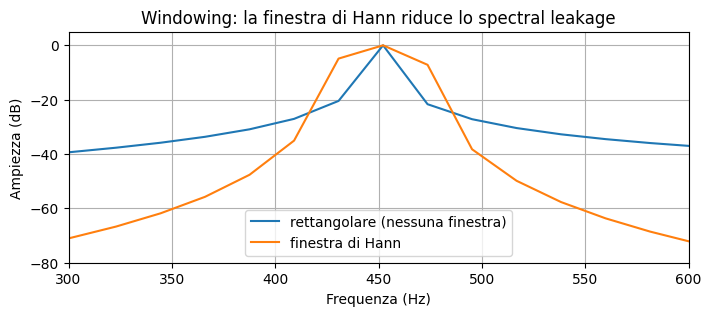

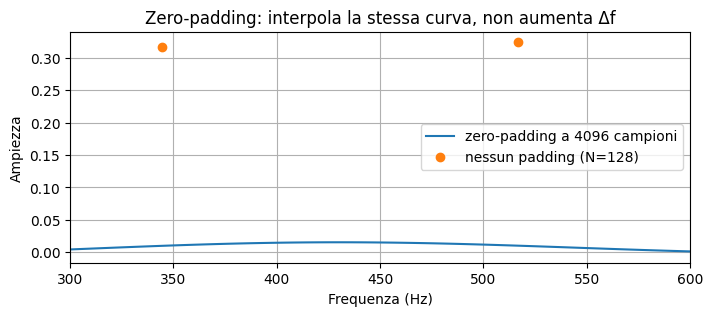

In [7]:
def spettro_ampiezza(x, fs, n_fft=None):
    """Calcola lo spettro di ampiezza one-sided di x tramite FFT.
    Restituisce una coppia (freqs, ampiezza): freqs sono le frequenze (Hz) di
    ciascun bin, ampiezza è il modulo del corrispondente coefficiente della FFT
    (normalizzato per n_fft, così il valore non dipende dalla lunghezza scelta).
    Il parametro n_fft, se maggiore di len(x), esegue implicitamente lo
    zero-padding (scipy.fft.fft aggiunge da solo gli zeri mancanti in coda).
    """
    n_fft = n_fft or len(x)                       # default: nessun padding, n_fft = lunghezza del segnale
    X = fft(x, n=n_fft)                            # FFT completa (bilatera): scipy.fft.fft
    freqs = fftfreq(n_fft, d=1 / fs)               # asse delle frequenze corrispondente ai bin della FFT
    meta = n_fft // 2                              # per segnali reali lo spettro è simmetrico: teniamo solo la metà positiva
    return freqs[:meta], np.abs(X[:meta]) / n_fft  # np.abs = modulo (ampiezza); si scarta la fase

# Demo — windowing: riduzione dello spectral leakage
# Generiamo un tono di prova a una frequenza NON allineata ai bin della FFT
# (con N=1024 e fs=22050, Δf ≈ 21.5 Hz: 450.3 Hz non è un multiplo esatto di Δf),
# così il leakage è ben visibile anche senza rumore aggiunto.
f_test = 450.3
n_seg = 1024
t_seg = np.arange(n_seg) / FS       # asse dei tempi (stessa logica vista nelle funzioni synth_*)
x_test = np.sin(2 * np.pi * f_test * t_seg)   # segnale di prova: sinusoide pura a 450.3 Hz

def spettro_db(x, fs, n_fft=None, finestra=None):
    """Come spettro_ampiezza, ma con due differenze pensate per questa demo:
    (1) applica opzionalmente una funzione finestra (es. np.hanning) al segnale
    prima della FFT, per confrontare rettangolare vs Hann; (2) restituisce
    l'ampiezza in decibel (dB), normalizzata rispetto al proprio picco (quindi il
    massimo è sempre 0 dB), per confrontare facilmente quanto le code laterali
    (il leakage) siano più o meno alte rispetto al picco principale.
    """
    n = len(x)
    n_fft = n_fft or n
    if finestra is not None:
        w = finestra(n)             # genera i coefficienti della finestra (es. np.hanning(n))
        xw = x * w                  # applica la finestra al segnale, campione per campione
        norm = w.sum()              # fattore di normalizzazione: compensa il guadagno medio della finestra
    else:
        xw = x                      # nessuna finestra = finestra rettangolare implicita
        norm = n
    X = fft(xw, n=n_fft)
    freqs = fftfreq(n_fft, d=1 / fs)
    meta = n_fft // 2
    amp = np.abs(X[:meta]) / (norm / 2)
    return freqs[:meta], 20 * np.log10(amp / np.max(amp) + 1e-12)  # dB relativi al picco (max = 0 dB)

# Confronto: stesso segnale, con e senza finestra
f_rect, a_rect = spettro_db(x_test, FS, finestra=None)        # rettangolare = nessuna finestra
f_hann, a_hann = spettro_db(x_test, FS, finestra=np.hanning)  # finestra di Hann (scipy/numpy)

plt.figure(figsize=(8, 3))
plt.plot(f_rect, a_rect, label="rettangolare (nessuna finestra)")
plt.plot(f_hann, a_hann, label="finestra di Hann")
plt.xlim(300, 600)     # zoom intorno al picco, per vedere bene le code laterali (leakage)
plt.ylim(-80, 5)
plt.xlabel("Frequenza (Hz)")
plt.ylabel("Ampiezza (dB)")
plt.title("Windowing: la finestra di Hann riduce lo spectral leakage")
plt.legend()
plt.grid(True)
plt.show()

# Demo — zero-padding: interpolazione, non nuova risoluzione
# Segnale volutamente corto (128 campioni): con così pochi campioni Δf = fs/N è
# grande e lo spettro "grezzo" ha pochi punti, distanti tra loro.
n_short = 128
t_short = np.arange(n_short) / FS
x_short = np.sin(2 * np.pi * 440 * t_short)   # tono puro a 440 Hz, ma su una finestra molto breve

f_nopad, a_nopad = spettro_ampiezza(x_short, FS)              # n_fft di default = 128: niente padding, pochi punti
f_pad,   a_pad   = spettro_ampiezza(x_short, FS, n_fft=4096)  # n_fft=4096 > 128: FFT esegue zero-padding automatico

plt.figure(figsize=(8, 3))
plt.plot(f_pad, a_pad, label="zero-padding a 4096 campioni")
plt.plot(f_nopad, a_nopad, "o", label=f"nessun padding (N={n_short})", markersize=6)
plt.xlim(300, 600)
plt.xlabel("Frequenza (Hz)")
plt.ylabel("Ampiezza")
plt.title("Zero-padding: interpola la stessa curva, non aumenta Δf")
plt.legend()
plt.grid(True)
plt.show()


### Demo 1 — FFT su un segnale sintetico noto

Verifichiamo che la FFT di una sinusoide nota (440 Hz) mostri un picco esattamente a 440 Hz.


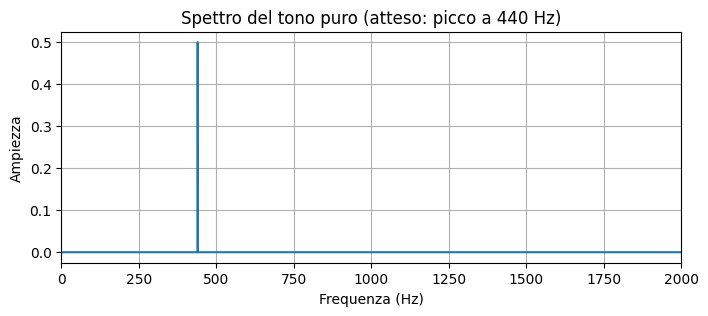

Frequenza del picco rilevato: 440.0 Hz


In [13]:
# spettro_ampiezza(...) è già definita sopra: la riusiamo per verificare il picco atteso
f, a = spettro_ampiezza(tono, FS)
plt.figure(figsize=(8, 3))
plt.plot(f, a)
plt.xlim(0, 2000)
plt.xlabel("Frequenza (Hz)")
plt.ylabel("Ampiezza")
plt.title("Spettro del tono puro (atteso: picco a 440 Hz)")
plt.grid(True)
plt.show()

picco = f[np.argmax(a)]
print(f"Frequenza del picco rilevato: {picco:.1f} Hz")


**Somma di sinusoidi + rumore.** Sommiamo due toni (440 Hz e 660 Hz, un intervallo di quinta) e
osserviamo due picchi distinti; il rumore bianco produce invece uno spettro piatto (energia distribuita
su tutte le frequenze).


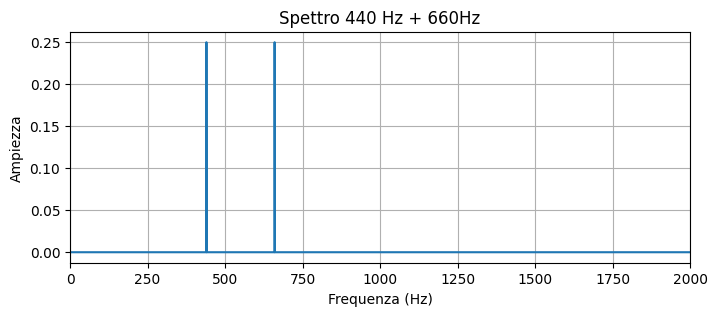

Frequenza del picco rilevato: 660.0 Hz


In [22]:
tono2 = synth_tone(f0=660.0)
somma = 0.5 * tono + 0.5 * tono2

# spettro_ampiezza(...) è già definita sopra: la riusiamo per verificare il picco atteso
f, a = spettro_ampiezza(somma, FS)
plt.figure(figsize=(8, 3))
plt.plot(f, a)
plt.xlim(0, 2000)
plt.xlabel("Frequenza (Hz)")
plt.ylabel("Ampiezza")
plt.title("Spettro 440 Hz + 660Hz")
plt.grid(True)
plt.show()

picco = f[np.argmax(a)]
print(f"Frequenza del picco rilevato: {picco:.1f} Hz")


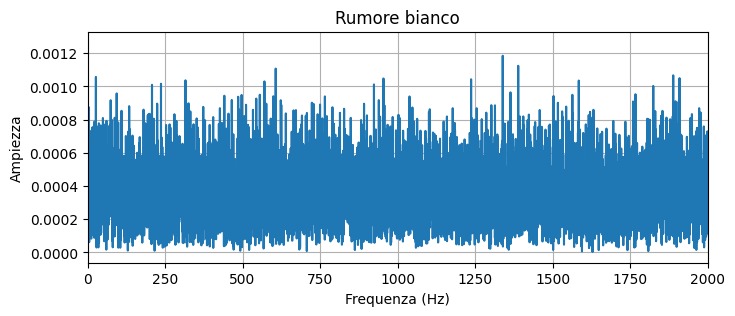

Frequenza del picco rilevato: 8818.3 Hz


In [20]:
f, a = spettro_ampiezza(rumore, FS)
plt.figure(figsize=(8, 3))
plt.plot(f, a)
plt.xlim(0, 2000)
plt.xlabel("Frequenza (Hz)")
plt.ylabel("Ampiezza")
plt.title("Rumore bianco")
plt.grid(True)
plt.show()

picco = f[np.argmax(a)]
print(f"Frequenza del picco rilevato: {picco:.1f} Hz")


**Effetto della lunghezza della finestra analizzata.** Analizzando solo una porzione breve del tono puro
la risoluzione in frequenza peggiora (righe più larghe); analizzandone una più lunga il picco diventa più
netto. Proviamo con 3 durate diverse dello stesso segnale.


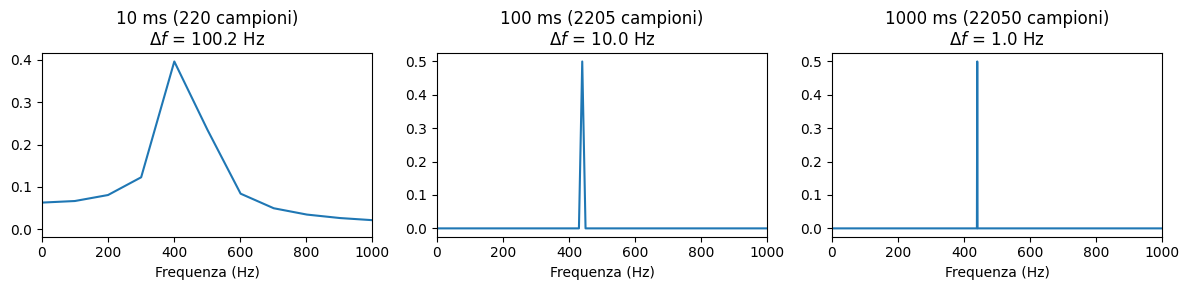

In [23]:
durate_prova = [0.01, 0.1, 1.0]  # secondi
fig, axes = plt.subplots(1, len(durate_prova), figsize=(12, 3))
for ax, d in zip(axes, durate_prova):
    n = int(FS * d)
    x = tono[:n]
    f, a = spettro_ampiezza(x, FS)
    ax.plot(f, a)
    ax.set_xlim(0, 1000)
    ax.set_title(f"{d*1000:.0f} ms ({n} campioni)\n$\\Delta f$ = {FS/n:.1f} Hz")
    ax.set_xlabel("Frequenza (Hz)")
plt.tight_layout()
plt.show()


### Demo 2 — FFT su segnali audio reali (voce, musica, rumore)

Confrontiamo lo spettro di ampiezza di voce, musica e rumore: dove si concentra l'energia in ciascun
caso? La musica e la voce mostrano energia concentrata su poche righe (fondamentale + armoniche/formanti),
il rumore mostra energia diffusa su tutto lo spettro.


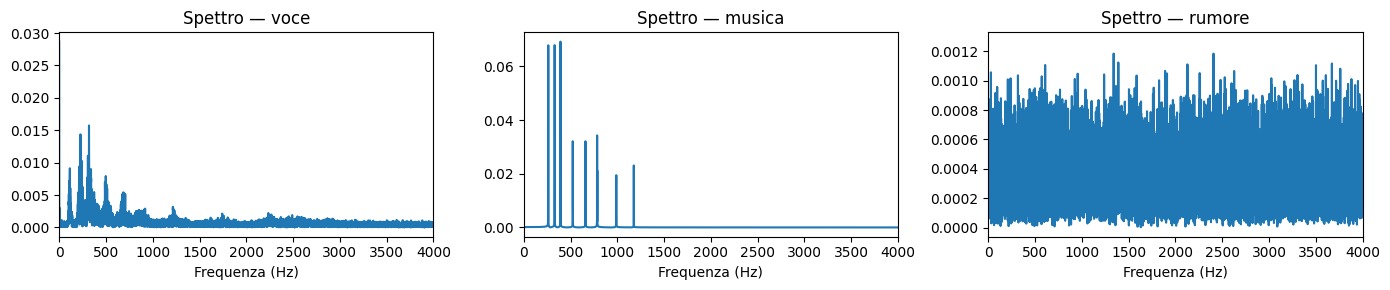

voce


musica


rumore


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, nome in zip(axes, ["voce", "musica", "rumore"]):
    x = segnali[nome]
    f, a = spettro_ampiezza(x, FS)
    ax.plot(f, a)
    ax.set_xlim(0, 4000)
    ax.set_title(f"Spettro — {nome}")
    ax.set_xlabel("Frequenza (Hz)")
plt.tight_layout()
plt.show()

for nome in ["voce", "musica", "rumore"]:
    print(nome)
    play(segnali[nome])


### Cos'è la STFT?

La FFT calcolata sull'intero segnale ci dice *quali* frequenze sono presenti in media, ma perde
completamente **quando** compaiono nel tempo (due segnali con lo stesso contenuto in frequenza ma in
ordine diverso avrebbero la stessa FFT globale). Per l'audio reale — dove il contenuto spettrale cambia
continuamente — questo non basta.

La **STFT** (Short-Time Fourier Transform) risolve il problema così:

1. si estrae dal segnale una **finestra breve** (poche decine di millisecondi);
2. si calcola la FFT **solo su quella finestra** (applicando anche una funzione di finestratura, es. Hann,
   per il windowing visto sopra);
3. la finestra scorre in avanti di un passo fisso, l'**hop size**, e si ripete il calcolo;
4. impilando tutti questi spettri "locali" uno accanto all'altro si ottiene lo **spettrogramma**: un'immagine
   con il tempo in ascissa, la frequenza in ordinata e l'ampiezza (in dB) rappresentata come colore/intensità.

I due parametri principali sono la **lunghezza della finestra** (`n_fft`, quanti campioni per volta) e
l'**hop size** (`hop_length`, di quanti campioni si avanza). C'è un compromesso strutturale, simile a un
principio di indeterminazione: una finestra più corta dà **migliore risoluzione temporale** ma **peggiore
risoluzione in frequenza** (Δf = fs/N più grande su N piccolo), e viceversa una finestra più lunga dà
migliore risoluzione in frequenza ma peggiore nel tempo. Non esiste una scelta "giusta" in assoluto: dipende
da cosa si vuole osservare.


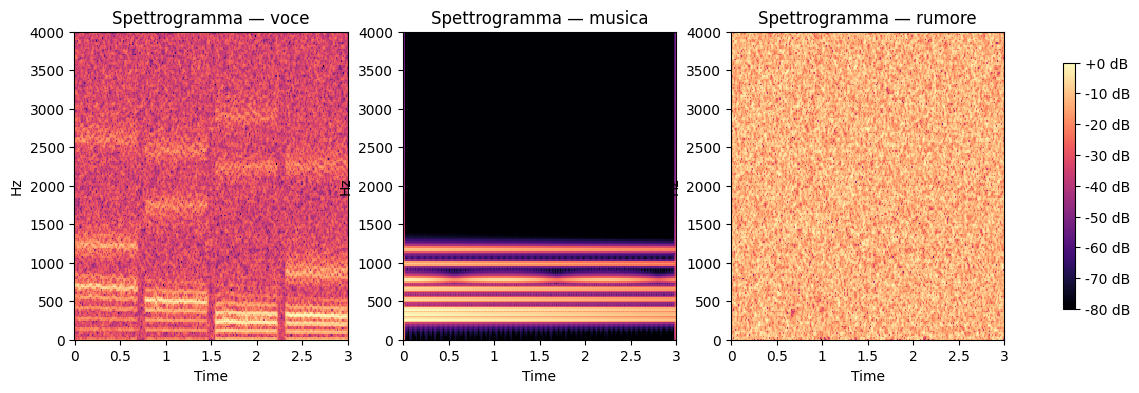

In [25]:
def mostra_spettrogramma(x, fs, titolo, ax=None):
    S = librosa.stft(x, n_fft=1024, hop_length=256)
    S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)
    img = librosa.display.specshow(S_db, sr=fs, hop_length=256,
                                    x_axis="time", y_axis="hz", ax=ax)
    ax.set_ylim(0, 4000)
    ax.set_title(titolo)
    return img

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
immagini = []
for ax, nome in zip(axes, ["voce", "musica", "rumore"]):
    img = mostra_spettrogramma(segnali[nome], FS, f"Spettrogramma — {nome}", ax=ax)
    immagini.append(img)
fig.colorbar(immagini[0], ax=axes, format="%+2.0f dB", shrink=0.8)
plt.show()


**Discussione guidata.** Nella voce si osservano bande orizzontali (i **formanti**) che **si spostano nel
tempo** passando da una "sillaba" all'altra — è proprio questa evoluzione temporale che la FFT globale (Demo
2) non riusciva a mostrare, e che la STFT rivela; nella musica righe armoniche nette e stabili (le note
suonate non cambiano); nel rumore energia diffusa su tutte le frequenze e su tutto il tempo.


---
## Parte 2 — Filtrare lo spettro: FIR, IIR ed equalizzatore

### Richiami teorici 

Nella Parte 1 abbiamo imparato a **leggere** lo spettro con la Trasformata di Fourier. Filtrare un segnale
significa **modificarne selettivamente lo spettro**: idealmente, moltiplicare l'ampiezza di alcune
frequenze per un fattore vicino a 1 (le lasciamo passare) e quella di altre per un fattore vicino a 0 (le
attenuiamo). In pratica questo si implementa nel dominio del tempo, con un filtro digitale:

- **Filtro passa-basso**: lascia passare le frequenze sotto una soglia (*cutoff*), attenua quelle sopra.
- **Filtro passa-alto**: l'opposto — attenua sotto il cutoff, lascia passare sopra.
- **FIR** (Finite Impulse Response — risposta all'impulso finita): combinazione lineare di un numero finito
  di campioni passati del segnale; sempre stabile, fase lineare (nessuna distorsione della forma d'onda),
  ma richiede ordini più alti (= più calcolo) per transizioni ripide.
- **IIR** (Infinite Impulse Response — risposta all'impulso infinita): usa anche i propri output passati
  (retroazione); ordini molto più bassi a parità di ripidità della transizione, ma fase non lineare e
  stabilità da verificare (a differenza del FIR, un IIR mal progettato può "esplodere").
- **Butterworth**: famiglia di filtri IIR con risposta più piatta possibile in banda passante (nessuna
  ondulazione), a scapito di una transizione più dolce verso la banda attenuata.
- **Chebyshev (tipo I)**: transizione più ripida a parità di ordine rispetto a Butterworth, a costo di un
  *ripple* (piccola ondulazione) nella banda passante.


### Demo 4 — Filtro passa-basso e passa-alto (Butterworth)

Applichiamo un filtro passa-basso Butterworth alla voce (per attutire le armoniche più alte) e
osserviamo/ascoltiamo l'effetto, confrontando lo spettro prima e dopo (collegandoci alle Demo 1–2).


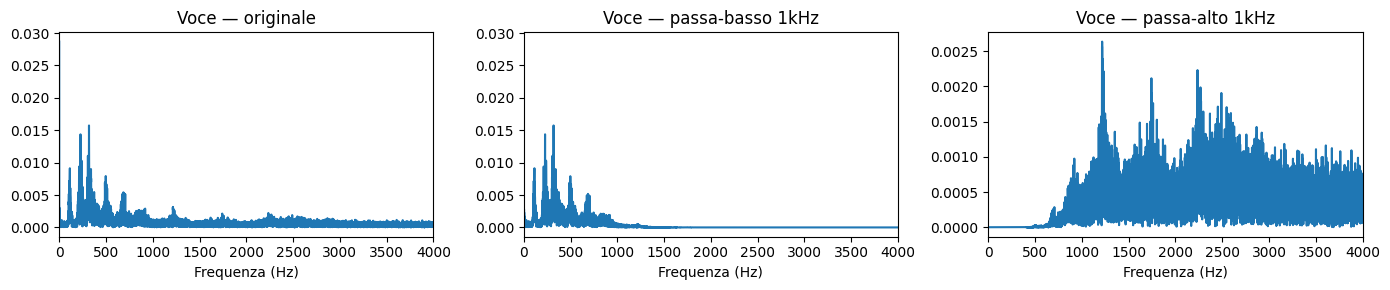

Originale


Passa-basso 1kHz


Passa-alto 1kHz


In [26]:
def filtro_butterworth(x, fs, cutoff, tipo="lowpass", ordine=4):
    nyq = fs / 2
    Wn = np.atleast_1d(cutoff) / nyq
    b, a = sig.butter(ordine, Wn, btype=tipo)
    return sig.filtfilt(b, a, x)

voce_lp = filtro_butterworth(voce, FS, cutoff=1000, tipo="lowpass")
voce_hp = filtro_butterworth(voce, FS, cutoff=1000, tipo="highpass")

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, (nome, x) in zip(axes, [("originale", voce), ("passa-basso 1kHz", voce_lp), ("passa-alto 1kHz", voce_hp)]):
    f, a = spettro_ampiezza(x, FS)
    ax.plot(f, a)
    ax.set_xlim(0, 4000)
    ax.set_title(f"Voce — {nome}")
    ax.set_xlabel("Frequenza (Hz)")
plt.tight_layout()
plt.show()

print("Originale");        play(voce)
print("Passa-basso 1kHz"); play(voce_lp)
print("Passa-alto 1kHz");  play(voce_hp)


### Demo 4b — FIR vs IIR, Butterworth vs Chebyshev

Confrontiamo la risposta in frequenza di quattro filtri passa-basso con lo stesso cutoff (1000 Hz) ma
famiglia/ordine diversi, per osservare a colpo d'occhio le differenze discusse a livello teorico.


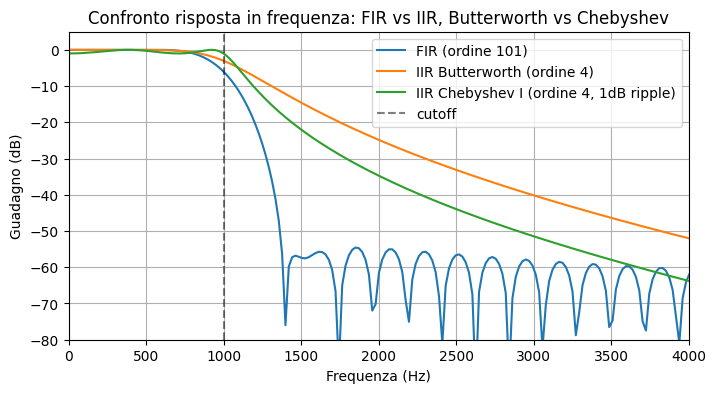

In [27]:
cutoff = 1000
nyq = FS / 2

b_fir = sig.firwin(101, cutoff / nyq)
b_butter, a_butter = sig.butter(4, cutoff / nyq)
b_cheb, a_cheb = sig.cheby1(4, 1, cutoff / nyq)  # 1 dB di ripple

filtri = {
    "FIR (ordine 101)": (b_fir, [1.0]),
    "IIR Butterworth (ordine 4)": (b_butter, a_butter),
    "IIR Chebyshev I (ordine 4, 1dB ripple)": (b_cheb, a_cheb),
}

plt.figure(figsize=(8, 4))
for nome, (b, a) in filtri.items():
    w, h = sig.freqz(b, a, fs=FS)
    plt.plot(w, 20 * np.log10(np.abs(h) + 1e-12), label=nome)
plt.axvline(cutoff, color="k", linestyle="--", alpha=0.5, label="cutoff")
plt.xlim(0, 4000)
plt.ylim(-80, 5)
plt.xlabel("Frequenza (Hz)")
plt.ylabel("Guadagno (dB)")
plt.legend()
plt.title("Confronto risposta in frequenza: FIR vs IIR, Butterworth vs Chebyshev")
plt.grid(True)
plt.show()


### Demo 5 — Equalizzatore grafico a N bande

Costruiamo un equalizzatore grafico: dividiamo lo spettro in $N$ bande (Butterworth passa-banda),
applichiamo un guadagno indipendente a ciascuna e sommiamo i contributi filtrati.


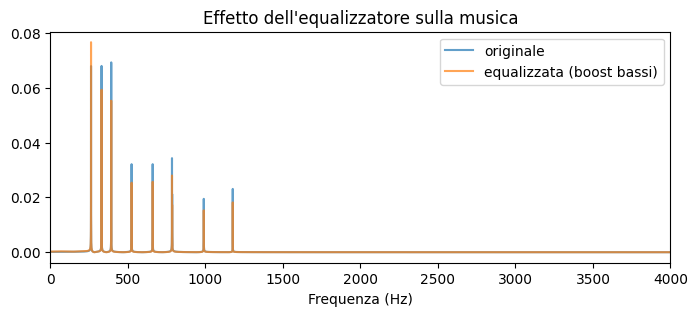

Musica originale


Musica equalizzata (boost bassi)


In [28]:
def crea_bande(n_bande, fmin=60, fmax=8000):
    """N bande log-spaziate tra fmin e fmax (in Hz)."""
    bordi = np.logspace(np.log10(fmin), np.log10(fmax), n_bande + 1)
    return list(zip(bordi[:-1], bordi[1:]))

def equalizzatore(x, fs, bande, guadagni_db, ordine=4):
    """Applica un equalizzatore grafico a N bande.
    bande: lista di tuple (f_low, f_high) in Hz
    guadagni_db: guadagno in dB per banda (stessa lunghezza di bande)
    """
    nyq = fs / 2
    y = np.zeros_like(x, dtype=float)
    for (f_low, f_high), g_db in zip(bande, guadagni_db):
        wn = [f_low / nyq, min(f_high / nyq, 0.999)]
        b, a = sig.butter(ordine, wn, btype="bandpass")
        filtrato = sig.filtfilt(b, a, x)
        y += filtrato * (10 ** (g_db / 20))
    picco = np.max(np.abs(y))
    return y / picco if picco > 0 else y

N_BANDE = 6
bande = crea_bande(N_BANDE)
preset_bassi_boost = [+6, +3, 0, 0, -3, -3]   # boost bassi, taglio alti

musica_eq = equalizzatore(musica, FS, bande, preset_bassi_boost)

f1, a1 = spettro_ampiezza(musica, FS)
f2, a2 = spettro_ampiezza(musica_eq, FS)
plt.figure(figsize=(8, 3))
plt.plot(f1, a1, label="originale", alpha=0.7)
plt.plot(f2, a2, label="equalizzata (boost bassi)", alpha=0.7)
plt.xlim(0, 4000)
plt.legend()
plt.xlabel("Frequenza (Hz)")
plt.title("Effetto dell'equalizzatore sulla musica")
plt.show()

print("Musica originale");  play(musica)
print("Musica equalizzata (boost bassi)"); play(musica_eq)
